# Recherche tabu

In [43]:
import numpy as np
from scipy.spatial import distance_matrix
from collections import deque
from functools import lru_cache
from functions import get_vrptw_instance
from functions import show 
import random 
import statistics
import copy  
from ipywidgets import IntProgress
from IPython.display import display


## Variables

In [44]:
# Instances
instance_name = "M/M-n101-k10.vrp"
data_set, data_set_solution = get_vrptw_instance(instance_name)

# DataSET
capacity = data_set['capacity']
coords = data_set['node_coord']
demand = data_set['demand']
nb_client=len(coords)-1

# dataSetSolution
BEST_SOLUTION = data_set_solution['routes']
BEST_SOLUTION_VALUE= total_travel_distance(BEST_SOLUTION)

#variable 
#GA
TAILLE_POPULATION = 10
NB_GENERATIONS = 10
TAUX_MUTATION= 0.2

#TABU
ITER_MAX = 20
NB_NEIGHBOR = 20
TAILLE_LISTE_TABOU = 20
NB_ITER_TABOU_POUR_ENFANT = 10

#Test
NB_TEST = 10

## Mathematics things

In [45]:
# Distance between two points
points = np.array(coords)

DISTANCE = distance_matrix(points, points)

## Giant tour manipulation

In [46]:
def merge(solution):
    """
    Merge a solution into a giant list
    Args:
        solution(list[list[int]]):
            A solution of the vrp.
            With k lists of c int elements.
            With k number of routes(trucks) and c number of client in the route.
    Returns:
        giant_tour(list[int]): Merge of the all routes into a giant list.
    """
    giant_tour = []
    for route in solution:
        for city in route:
            if city != 0:
                giant_tour.append(city)
    return giant_tour

In [47]:
def split(giant_tour):
    """
    Split the giant tour into multiple feasible routes.
    Args:
        giant_tour (list[int]): A giant tour representing a full permutation
        of all clients.

    Returns:
        sol (list[list[int]]): A list of routes, where each route is a list
        of clients assigned to the same truck, respecting capacity constraints.
    """
    route=[]
    sol =[]
    cost =0 
    for client in giant_tour:
        if cost + demand[client] <= capacity:
            route.append(client)
            cost += demand[client]
        else :
            sol.append(route)
            cost = demand[client]
            route = [client] 
    sol.append(route)

    return sol 

## random solution

In [48]:
import matplotlib.pyplot as plt

def random_solution():
    """
    Generate a random VRP solution.
    Args:
        None

    Returns:
        solution (list[list[int]]): A feasible solution composed of several routes,
        obtained by generating a random giant tour and splitting it into routes
        respecting the truck capacity constraints.
    """

    giant_tour = random.sample(range(nb_client + 1), k=nb_client + 1)
    solution = split(giant_tour)
    return solution


# Neighborhood

In [49]:
def neighborhood(solution, nb_neighbors, nb_swaps_per_neighbor):
    """
    Find nb_neighbors solution's neighbor
    Args:
        solution(list[list[int]]):
            A solution of the vrp.
            With k lists of c int elements.
            With k number of routes(trucks) and c number of client in the route.
        nb_neighbors(int):
            number of neighbors that we want to have for the solution
        nb_swaps_per_neighbor(int):
            number of swap per neighbor.
            if nb_swaps_per_neighbor = 1 we swap 2 values between them
            if nb_swaps_per_neighbor = 2 we swap two time 2 differente values between them
    Returns:
        neighbors(list[solution]):
            list of nb_neighbors solution's neighbor
    """
    neighbors = []

    giant_tour = merge(solution)
    size_giant_tour = len(giant_tour)

    i, j = random.sample(range(size_giant_tour), 2)
    for _ in range(nb_neighbors):
        neighbor_giant_tour = giant_tour.copy()
        for _ in range(nb_swaps_per_neighbor):
            i, j = random.sample(range(size_giant_tour), 2)
            neighbor_giant_tour[i], neighbor_giant_tour[j] = neighbor_giant_tour[j], neighbor_giant_tour[i]
        neighbors.append(split(neighbor_giant_tour))
    return neighbors

# Weight evaluation

In [50]:

def total_travel_distance(solution):
    dist_tot = 0
    for route in solution:
        full_route = [0] + route + [0]
        for client in range(len(full_route)-1):
            origin = full_route[client]
            destination = full_route[client + 1]
            dist_tot += DISTANCE[origin, destination]

    return dist_tot



# TABOU RESEARCH 

In [51]:

def tabu_search(initial_solution, tabu_size, iter_max, nb_neighbors, nb_swaps_per_neighbor):
    """
    1. We start from an element of our search set that we state current element
    2. We consider the neighbourhood of the current element, we choose the best of them
    as a new current element, among those missing from the tabu list, and we add it
    to the tabu list
    3. We run a loop until the output condition is reached.
    """
    nb_iter = 0
    tabu_list = deque(maxlen=tabu_size)

    # variables solutions for finding the neighbour optimal not tabu
    current_solution = initial_solution
    best = initial_solution
    best_global = initial_solution

    # variables values for finding neighbour optimal not tabu
    value_best = total_travel_distance(initial_solution)
    value_best_global = value_best


    while (nb_iter < iter_max):
        value_best = float('inf')
        # we go through all the neighbours of the current solution
        for neighbor in neighborhood(current_solution,nb_neighbors,nb_swaps_per_neighbor):
            neighbor_tuple =[ route for route in neighbor]
            if total_travel_distance(neighbor_tuple) < value_best and neighbor_tuple not in tabu_list:
                value_best = total_travel_distance(neighbor_tuple)
                best = neighbor_tuple

        # we update the best solution encountered since the beginning
        if value_best < value_best_global:
            best_global = best
            value_best_global = value_best
            nb_iter = 0
        else:
            nb_iter += 1

        # we go to the best non-tabu neighbour found
        current_solution = best

        # we update the tabu list
        tabu_list.append(current_solution)

    # ensure the returned solution has the original expected type: list of lists
    return best_global


In [52]:
# multi-start of n iterations
def multi_start(solution, tabu_size,iter_max, nb_neighbors,nb_swaps_per_neighbor, n_iter ):

    sol_max = None
    val_max = float("inf")
    for _ in range (n_iter):
        solution = random_solution()
        sol_courante = tabu_search(solution, tabu_size,iter_max, nb_neighbors,nb_swaps_per_neighbor )
        val_courante = total_travel_distance(sol_courante)
        if (val_courante < val_max):
            val_max = val_courante
            sol_max = sol_courante
    return val_max, sol_max

#test
# 
 
print(best_solution)
print(total_travel_distance(best_solution))

rand =random_solution()
print(rand)
print(total_travel_distance(rand))

best=tabu_search(rand,tabu_size,iter_max,nb_neighbors,nb_swaps_per_neighbor)
print(best)
print(total_travel_distance(best))

multi_val, multi_sol = multi_start(rand,tabu_size,iter_max,nb_neighbors,nb_swaps_per_neighbor,n_iter)
print(multi_sol)
print(multi_val)


neighbor = neighborhood(rand, 1, 3)
print(neighbor)
print(total_travel_distance(neighbor[0]))

show(rand, data_set)
show(best, data_set)
show(BEST_SOLUTION,data_set)


In [53]:
def ini_population():
    population = []
    for _ in range(TAILLE_POPULATION):
        population.append(random_solution())
    return population

def evaluation(population):
    # À l'intérieur de la boucle de génération
    meilleur_distance_generation = float("inf")
    meilleur_de_la_generation = None
    meilleure_solution_globale= None
    for individu in population:
        dist_individu = total_travel_distance(individu)
        if dist_individu < meilleur_distance_generation :
            # Mise à jour du meilleur global (élitisme)
            meilleur_distance_generation =  dist_individu
            meilleur_de_la_generation = individu

    if meilleure_solution_globale is None or meilleur_distance_generation < total_travel_distance(meilleure_solution_globale):
        meilleure_solution_globale = copy.deepcopy(meilleur_de_la_generation)
    
    return meilleure_solution_globale

def selection_par_tournoi(population, k=6):
    # S'assurer qu'on sélectionne un nombre pair de parents
    nb_parents = TAILLE_POPULATION + (TAILLE_POPULATION % 2)  # arrondi au pair supérieur
    liste_parents = []
    k = min(max(2, k), len(population))
    for _ in range(nb_parents):
        # 1. Choisir k participants au hasard
        participants = random.sample(population, k)
        
        # 2. Trouver le gagnant (celui avec le coût minimum)
        gagnant = evaluation(participants)
        
        # 3. Ajouter le gagnant à la liste
        liste_parents.append(gagnant)
        
    return liste_parents

def crossover(p1,p2):
    p1 = merge(p1)
    p2=merge(p2)
    n =len(p1)
    a, b = sorted(random.sample(range(n), 2))
    child =n* [None]
    child[a:b]=p1[a:b]

    rest =[x for x in p2 if x not in child]
    pos=0
    for i in range(n) :
        if child[i] is None :
            child[i]=rest[pos]
            pos+=1
    return split(child)


def mutation_simple(initial_child):
    initial_child=merge(initial_child)
    a, b = random.sample(range(len(initial_child)), 2)
    gene = initial_child.pop(a)
    initial_child.insert(b, gene)
    return split(initial_child)

def amelioration_child(new_population):
    # À l'intérieur de la boucle de génération, après l'étape 5
    population_amelioree = []
    
    for enfant in new_population:
        # Appliquer la TS pour améliorer l'enfant
        enfant_ameliore = tabu_search(enfant,TAILLE_LISTE_TABOU, NB_ITER_TABOU_POUR_ENFANT, NB_NEIGHBOR , nb_swaps_per_neighbor=1)
        population_amelioree.append(enfant_ameliore)

    return population_amelioree

def new_gen(parents_selectionnes):
    # À l'intérieur de la boucle de génération
    new_population = []
    # Assurer que nous avons un nombre pair de parents
    nb_pairs = len(parents_selectionnes) // 2
    
    for i in range(nb_pairs):
        parent1 = parents_selectionnes[2*i]
        parent2 = parents_selectionnes[2*i + 1]

        enfant = crossover(parent1, parent2)

        if random.random() < TAUX_MUTATION:
            enfant = mutation_simple(enfant)

        new_population.append(enfant)

    return new_population

def elitisme(population, best_global_solution):
    # Élitisme : s'assurer que le meilleur individu survit
    # (Il faut trouver le plus mauvais de la nouvelle pop et le remplacer)
    pire_distance_generation = -float("inf")
    pire_de_la_generation = None
    piree_solution_globale= None
    index_pire = 0  # initialisation par défaut
    
    for i, individu in enumerate(population):
        dist_individu = total_travel_distance(individu)
        if dist_individu > pire_distance_generation :
            # Mise à jour du pire global (élitisme)
            pire_distance_generation =  dist_individu
            pire_de_la_generation = individu
            index_pire = i

    # Remplacer le pire par le meilleur global
    population[index_pire] = best_global_solution
    return population


def ga():
    curr_pop = ini_population()

    for _ in range(NB_GENERATIONS):
        bar2.value +=1
        best_sol=evaluation(curr_pop)
        parents = selection_par_tournoi(curr_pop, k=6)
        better_pop = new_gen(parents)
        #better_pop= amelioration_child(better_pop)
        pop_final=elitisme(better_pop,best_sol)
        curr_pop = pop_final

    bar2.value = 0
    best_global_solution= evaluation(curr_pop)
    best_global_value=total_travel_distance(best_global_solution)
    return best_global_solution, best_global_value




IntProgress(value=0, layout=Layout(width='100%'), max=10)

IntProgress(value=0, layout=Layout(width='100%'), max=33)

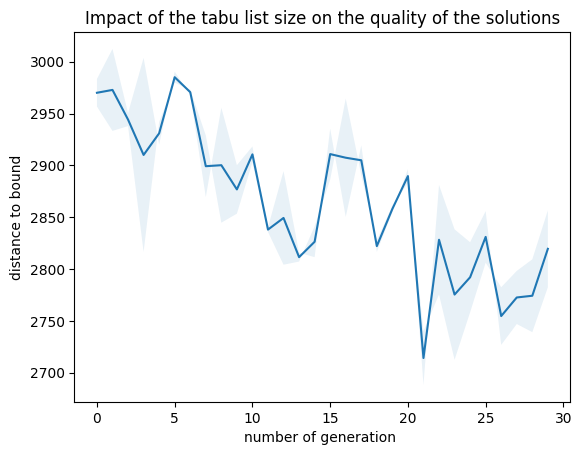

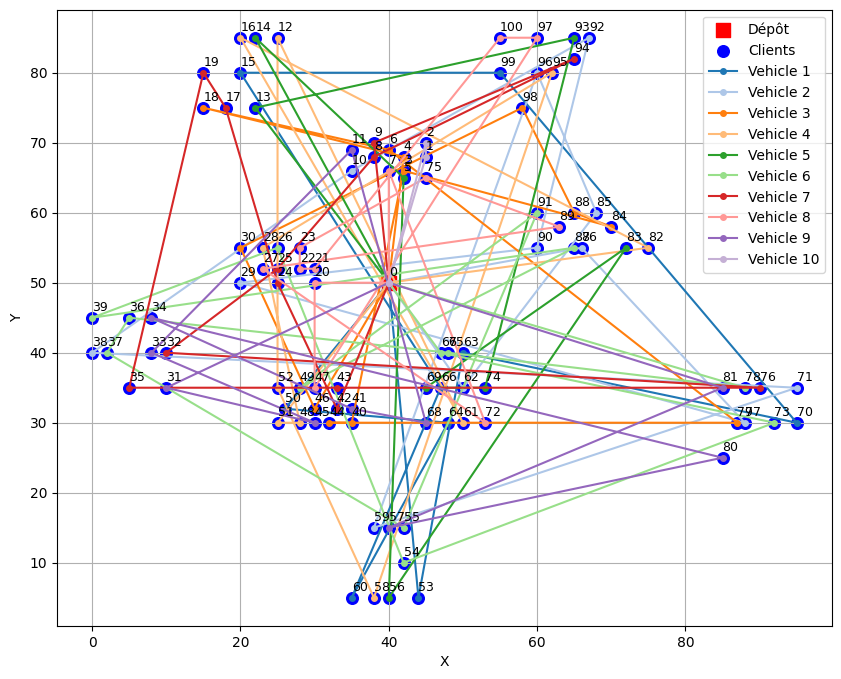

3905.8714218125033


In [55]:



# we display the progress bar
nb_steps_bar = 10
bar = IntProgress(min=0, max=nb_steps_bar, layout={"width" : "100%"})
display(bar)
nb_steps_bar2= NB_GENERATIONS
bar2= IntProgress(min=0, max=nb_steps_bar2, layout={"width" : "100%"})
display(bar2)
# to store results
moyennes = []
bornes = []
deviations = []

random.seed(a=3)

# this time we loop on the size of the tabu list
for i in range (10,40):
    NB_GENERATIONS=i
    moyenne=[]
    deviation=[]
    for j in range (NB_TEST):
        sol, value = ga()
        distance = value- BEST_SOLUTION_VALUE 
        bornes.append(distance)
        moyenne.append(distance)
        deviation.append(np.mean(moyenne)-distance)

    moyennes.append(np.mean(moyenne))
    deviations.append(np.mean(deviation))
    bar.value += 1

# we hide the progress bar
bar.close()
bar2.close()

plt.plot(range(30), moyennes)

# display of the standard deviation strip
plt.fill_between(range(30),
 np.subtract(moyennes, deviations), # high bound
 np.add(moyennes, deviations), # lower bound
 alpha=.1) # transparency
plt.xlabel("number of generation ")
plt.ylabel("distance to bound")
plt.title("Impact of the tabu list size on the quality of the solutions")
plt.show()

show(sol,data_set)
print(value)

In [ ]:

# we display the progress bar
nb_steps_bar = NB_TEST
bar = IntProgress(min=0, max=nb_steps_bar, layout={"width" : "100%"})
display(bar)
nb_steps_bar2= NB_GENERATIONS
bar2= IntProgress(min=0, max=nb_steps_bar2, layout={"width" : "100%"})
display(bar2)
nb_steps_bar3= 15
bar3= IntProgress(min=0, max=nb_steps_bar3, layout={"width" : "100%"})
display(bar3)

# to store results
moyennes = []
bornes = []
deviations = []

random.seed(a=3)

# this time we loop on the size of the tabu list
for i in range (50,100):
    TAILLE_POPULATION=i
    moyenne=[]
    deviation=[]
    for j in range (NB_TEST):
        sol, value = ga()
        distance = value- BEST_SOLUTION_VALUE 
        bornes.append(distance)
        moyenne.append(distance)
        deviation.append(np.mean(moyenne)-distance)
        bar.value += 1

    moyennes.append(np.mean(moyenne))
    deviations.append(np.mean(deviation))
    bar3.value += 1
    bar.value = 0
    

# we hide the progress bar
bar.close()
bar2.close()

plt.plot(range(10,30), moyennes)

# display of the standard deviation strip
plt.fill_between(range(10,30),
 np.subtract(moyennes, deviations), # high bound
 np.add(moyennes, deviations), # lower bound
 alpha=.1) # transparency
plt.xlabel("population size ")
plt.ylabel("distance to bound")
plt.title("Impact of the population size on the quality of the solutions")
plt.show()

show(sol,data_set)
print(value)

IntProgress(value=0, layout=Layout(width='100%'), max=10)

IntProgress(value=0, layout=Layout(width='100%'), max=10)

IntProgress(value=0, layout=Layout(width='100%'), max=15)

TypeError: can only concatenate list (not "int") to list

ValueError: x and y must have same first dimension, but have shapes (50,) and (0,)

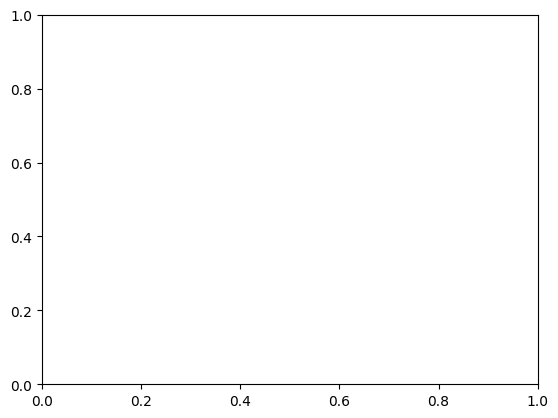

In [ ]:

plt.plot(range(50,100), moyennes)

# display of the standard deviation strip
plt.fill_between(range(50,100),
 np.subtract(moyennes, deviations), # high bound
 np.add(moyennes, deviations), # lower bound
 alpha=.1) # transparency
plt.xlabel("population size ")
plt.ylabel("distance to bound")
plt.title("Impact of the population size on the quality of the solutions")
plt.show()

show(sol,data_set)
print(value)

In [ ]:

# we display the progress bar
nb_steps_bar = NB_TEST
bar = IntProgress(min=0, max=nb_steps_bar, layout={"width" : "100%"})
display(bar)
nb_steps_bar2= NB_GENERATIONS
bar2= IntProgress(min=0, max=nb_steps_bar2, layout={"width" : "100%"})
display(bar2)
nb_steps_bar3= 15
bar3= IntProgress(min=0, max=nb_steps_bar3, layout={"width" : "100%"})
display(bar3)

# to store results
moyennes = []
bornes = []
deviations = []

random.seed(a=3)

# this time we loop on the size of the tabu list
for i in range (10,30):
    TAILLE_POPULATION=i
    moyenne=[]
    deviation=[]
    for j in range (NB_TEST):
        sol, value = ga()
        distance = value- BEST_SOLUTION_VALUE 
        bornes.append(distance)
        moyenne.append(distance)
        deviation.append(np.mean(moyenne)-distance)
        bar.value += 1

    moyennes.append(np.mean(moyenne))
    deviations.append(np.mean(deviation))
    bar3.value += 1
    bar.value = 0
    

# we hide the progress bar
bar.close()
bar2.close()

plt.plot(range(10,30), moyennes)

# display of the standard deviation strip
plt.fill_between(range(10,30),
 np.subtract(moyennes, deviations), # high bound
 np.add(moyennes, deviations), # lower bound
 alpha=.1) # transparency
plt.xlabel("population size ")
plt.ylabel("distance to bound")
plt.title("Impact of the population size on the quality of the solutions")
plt.show()

show(sol,data_set)
print(value)

IntProgress(value=0, layout=Layout(width='100%'), max=10)

IntProgress(value=0, layout=Layout(width='100%'), max=10)

IntProgress(value=0, layout=Layout(width='100%'), max=15)

TypeError: can only concatenate list (not "int") to list